# GMRQ for TICA and MSM Pipeline for MD Simulations Data

In [ ]:
##### This Jupyter notebook has calculates GMRQ scores for number of microstates 

##### Author: SB (latest update: Aug 9, 2024)
##### Updated: MR (latest update: Mar 25, 2025) 

# Step 0: Imports 

In [ ]:
##### Please ensure you have properly set up the conda environment with all libraries. (MSM Builder and MD traj)

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import os
from scipy.stats import f_oneway
from scipy import stats

# Step 1: Import Data 

In [4]:
os.chdir('YOUR_PATH')

In [5]:
kmeans_3d_means=[]
kmeans_3d_stds=[]
for microstates in (50,100,150,200, 250, 300, 350, 400, 450, 500):
    test=np.loadtxt('/YOUR_PATH/GMRQ/GMRQscore_3d_%d_l100.txt' %(microstates))
    kmeans_3d_means.append(np.nanmean(test))
    kmeans_3d_stds.append(np.nanstd(test))

# Step 2: Visualization

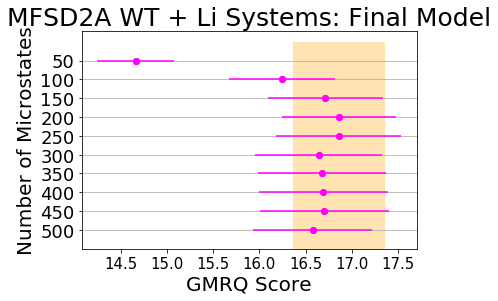

In [7]:
plt.scatter(kmeans_3d_means,range(len(kmeans_3d_means),0,-1), color='magenta')
plt.errorbar(kmeans_3d_means,range(len(kmeans_3d_means),0,-1), xerr=kmeans_3d_stds,fmt="o",color='magenta')

plt.grid(axis='y')
plt.yticks(range(1,11),('500','450', '400', '350', '300','250','200','150','100','50'),
          fontsize=18)

#plt.legend(labels=['K-Means 2D','K-Means 3D'],loc='lower left',fontsize=20)
plt.title('MFSD2A WT + Li Systems: Final Model',fontsize=25)
plt.xlabel('GMRQ Score', fontsize=20)
plt.ylabel('Number of Microstates', fontsize=20)
plt.xticks(fontsize=15)
plt.bar(x=np.percentile(kmeans_3d_means,95),height=11,width=1,
       alpha=.3,color='orange')
plt.show()

# OTHER EXAMPLES OF VISUALIZATION 

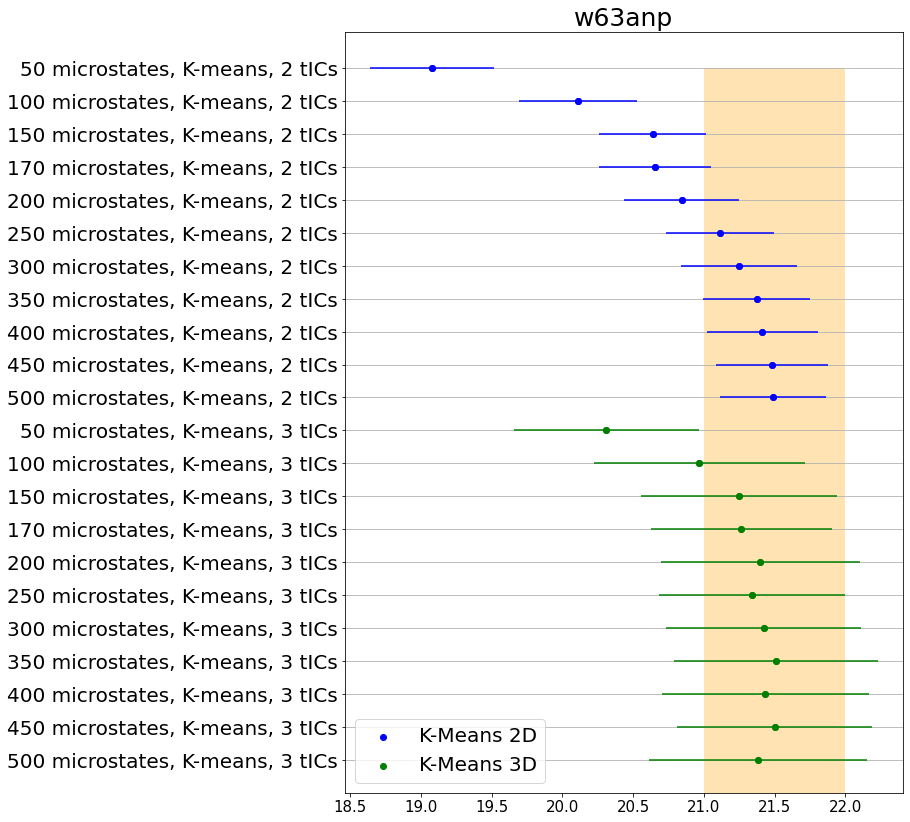

In [43]:
plt.figure(figsize=(10,14))

plt.scatter(kmeans_2d_means,range(22,11,-1),color='blue')
plt.errorbar(kmeans_2d_means,range(22,11,-1),xerr=kmeans_2d_stds,fmt="o",color='blue')
plt.scatter(kmeans_3d_means,range(11,0,-1),color='green')
plt.errorbar(kmeans_3d_means,range(11,0,-1),xerr=kmeans_3d_stds,fmt="o",color='green')

plt.grid(axis='y')
plt.yticks(range(1,23),('500 microstates, K-means, 3 tICs','450 microstates, K-means, 3 tICs','400 microstates, K-means, 3 tICs','350 microstates, K-means, 3 tICs','300 microstates, K-means, 3 tICs','250 microstates, K-means, 3 tICs','200 microstates, K-means, 3 tICs','170 microstates, K-means, 3 tICs','150 microstates, K-means, 3 tICs','100 microstates, K-means, 3 tICs','50 microstates, K-means, 3 tICs',
                       '500 microstates, K-means, 2 tICs','450 microstates, K-means, 2 tICs','400 microstates, K-means, 2 tICs','350 microstates, K-means, 2 tICs','300 microstates, K-means, 2 tICs','250 microstates, K-means, 2 tICs','200 microstates, K-means, 2 tICs','170 microstates, K-means, 2 tICs','150 microstates, K-means, 2 tICs','100 microstates, K-means, 2 tICs','50 microstates, K-means, 2 tICs'),
          fontsize=20)

plt.legend(labels=['K-Means 2D','K-Means 3D'],loc='lower left',fontsize=20)
plt.title('%s' %model,fontsize=25)
plt.xticks(fontsize=15)
plt.bar(x=np.percentile(kmeans_2d_means+kmeans_3d_means,95),height=22,width=1,
       alpha=.3,color='orange')
plt.show()


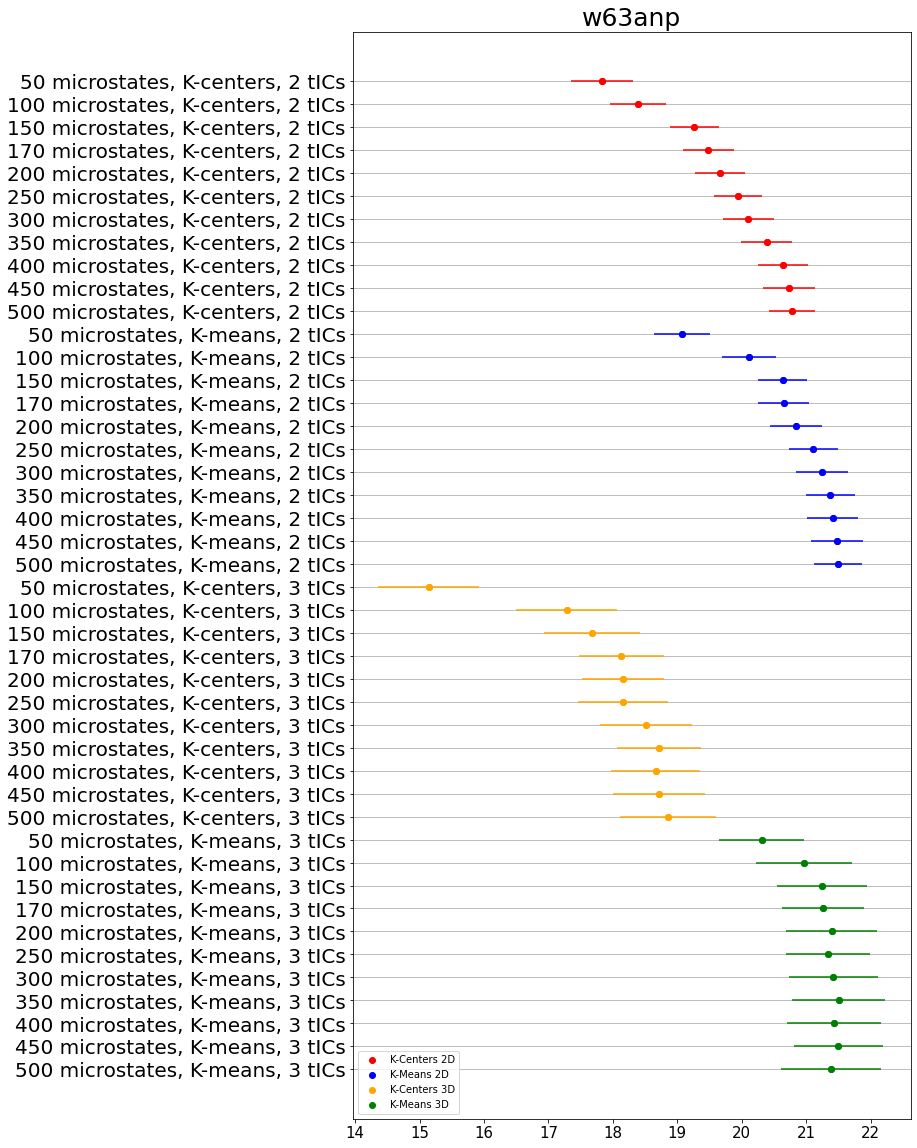

In [48]:
plt.figure(figsize=(10,20))

plt.scatter(kcent_2d_means,range(44,33,-1),color='red')
plt.errorbar(kcent_2d_means,range(44,33,-1),xerr=kcent_2d_stds,fmt="o",color='red')
plt.scatter(kmeans_2d_means,range(33,22,-1),color='blue')
plt.errorbar(kmeans_2d_means,range(33,22,-1),xerr=kmeans_2d_stds,fmt="o",color='blue')
plt.scatter(kcent_3d_means,range(22,11,-1),color='orange')
plt.errorbar(kcent_3d_means,range(22,11,-1),xerr=kcent_3d_stds,fmt="o",color='orange')
plt.scatter(kmeans_3d_means,range(11,0,-1),color='green')
plt.errorbar(kmeans_3d_means,range(11,0,-1),xerr=kmeans_3d_stds,fmt="o",color='green')


plt.grid(axis='y')
plt.yticks(range(1,45),('500 microstates, K-means, 3 tICs','450 microstates, K-means, 3 tICs','400 microstates, K-means, 3 tICs','350 microstates, K-means, 3 tICs','300 microstates, K-means, 3 tICs','250 microstates, K-means, 3 tICs','200 microstates, K-means, 3 tICs','170 microstates, K-means, 3 tICs','150 microstates, K-means, 3 tICs','100 microstates, K-means, 3 tICs','50 microstates, K-means, 3 tICs',
                       '500 microstates, K-centers, 3 tICs','450 microstates, K-centers, 3 tICs','400 microstates, K-centers, 3 tICs','350 microstates, K-centers, 3 tICs','300 microstates, K-centers, 3 tICs','250 microstates, K-centers, 3 tICs','200 microstates, K-centers, 3 tICs','170 microstates, K-centers, 3 tICs','150 microstates, K-centers, 3 tICs','100 microstates, K-centers, 3 tICs','50 microstates, K-centers, 3 tICs',
                         '500 microstates, K-means, 2 tICs','450 microstates, K-means, 2 tICs','400 microstates, K-means, 2 tICs','350 microstates, K-means, 2 tICs','300 microstates, K-means, 2 tICs','250 microstates, K-means, 2 tICs','200 microstates, K-means, 2 tICs','170 microstates, K-means, 2 tICs','150 microstates, K-means, 2 tICs','100 microstates, K-means, 2 tICs','50 microstates, K-means, 2 tICs',
                         '500 microstates, K-centers, 2 tICs','450 microstates, K-centers, 2 tICs','400 microstates, K-centers, 2 tICs','350 microstates, K-centers, 2 tICs','300 microstates, K-centers, 2 tICs','250 microstates, K-centers, 2 tICs','200 microstates, K-centers, 2 tICs','170 microstates, K-centers, 2 tICs','150 microstates, K-centers, 2 tICs','100 microstates, K-centers, 2 tICs','50 microstates, K-centers, 2 tICs'),
          fontsize=20)
plt.legend(labels=['K-Centers 2D','K-Means 2D','K-Centers 3D','K-Means 3D'],loc='lower left')
plt.title('%s' %model,size=25)
plt.xticks(size=15)
plt.show()
